<a href="https://colab.research.google.com/github/alexandrumoldovan1/housing-prices-ml/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install visualization libraries
!pip install ydata-profiling -q
!pip install plotly -q

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00
Libraries imported successfully!


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/ColabProjects/housing-prices-ml'
PROCESSED_DATA_PATH = f'{DRIVE_PATH}/processed_data'
OUTPUTS_PATH = f'{DRIVE_PATH}/outputs'

# Load the master DataFrame from Notebook 01
df = pd.read_parquet(f'{PROCESSED_DATA_PATH}/raw_data.parquet')

print(f"Data loaded successfully!")
print(f"   Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Mounted at /content/drive
Data loaded successfully!
   Shape: 239,722 rows x 23 columns


In [3]:
# Display column names and data types
print("COLUMNS AND DATA TYPES:\n")
print(df.dtypes.to_string())

print(f"\nTotal columns: {df.shape[1]}")
print(f"Total rows: {df.shape[0]:,}")

COLUMNS AND DATA TYPES:

BOROUGH                                  float64
NEIGHBORHOOD                              object
BUILDING CLASS CATEGORY                   object
TAX CLASS AT PRESENT                      object
BLOCK                                    float64
LOT                                      float64
EASE-MENT                                float64
BUILDING CLASS AT PRESENT                 object
ADDRESS                                   object
APARTMENT NUMBER                          object
ZIP CODE                                 float64
RESIDENTIAL UNITS                        float64
COMMERCIAL UNITS                         float64
TOTAL  UNITS                             float64
LAND  SQUARE FEET                        float64
GROSS  SQUARE FEET                       float64
YEAR BUILT                               float64
TAX CLASS AT TIME OF SALE                float64
BUILDING CLASS AT TIME OF SALE            object
SALE PRICE                               flo

In [4]:
# Analyze missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("MISSING VALUES PER COLUMN:\n")
print(missing_df.to_string())

MISSING VALUES PER COLUMN:

                                Missing Count  Missing %
EASE-MENT                              239722     100.00
APARTMENT NUMBER                       182429      76.10
LAND  SQUARE FEET                      107643      44.90
GROSS  SQUARE FEET                     107641      44.90
COMMERCIAL UNITS                        99359      41.45
RESIDENTIAL UNITS                       58132      24.25
TOTAL  UNITS                            49848      20.79
YEAR BUILT                              15908       6.64
ZIP CODE                                   33       0.01
LOT                                         0       0.00
BLOCK                                       0       0.00
BOROUGH                                     0       0.00
NEIGHBORHOOD                                0       0.00
TAX CLASS AT PRESENT                        0       0.00
BUILDING CLASS CATEGORY                     0       0.00
ADDRESS                                     0       0.00
BUI

In [5]:
# Basic statistics for SALE PRICE
print("SALE PRICE - DESCRIPTIVE STATISTICS:\n")
print(df['SALE PRICE'].describe().apply(lambda x: f'{x:,.2f}').to_string())

# Count of zero/very low prices (non-arms-length transactions)
zero_price = (df['SALE PRICE'] == 0).sum()
low_price = ((df['SALE PRICE'] > 0) & (df['SALE PRICE'] < 10000)).sum()

print(f"\nTransactions with SALE PRICE = 0: {zero_price:,} ({zero_price/len(df)*100:.2f}%)")
print(f"Transactions with 0 < SALE PRICE < $10,000: {low_price:,} ({low_price/len(df)*100:.2f}%)")

SALE PRICE - DESCRIPTIVE STATISTICS:

count          239,722.00
mean         1,529,754.97
std         10,734,334.95
min                  0.00
25%                  0.00
50%            490,000.00
75%            999,000.00
max      1,080,000,000.00

Transactions with SALE PRICE = 0: 80,931 (33.76%)
Transactions with 0 < SALE PRICE < $10,000: 5,032 (2.10%)


Valid transactions (price > $10,000): 153,646
Removed: 86,076 (35.91%)


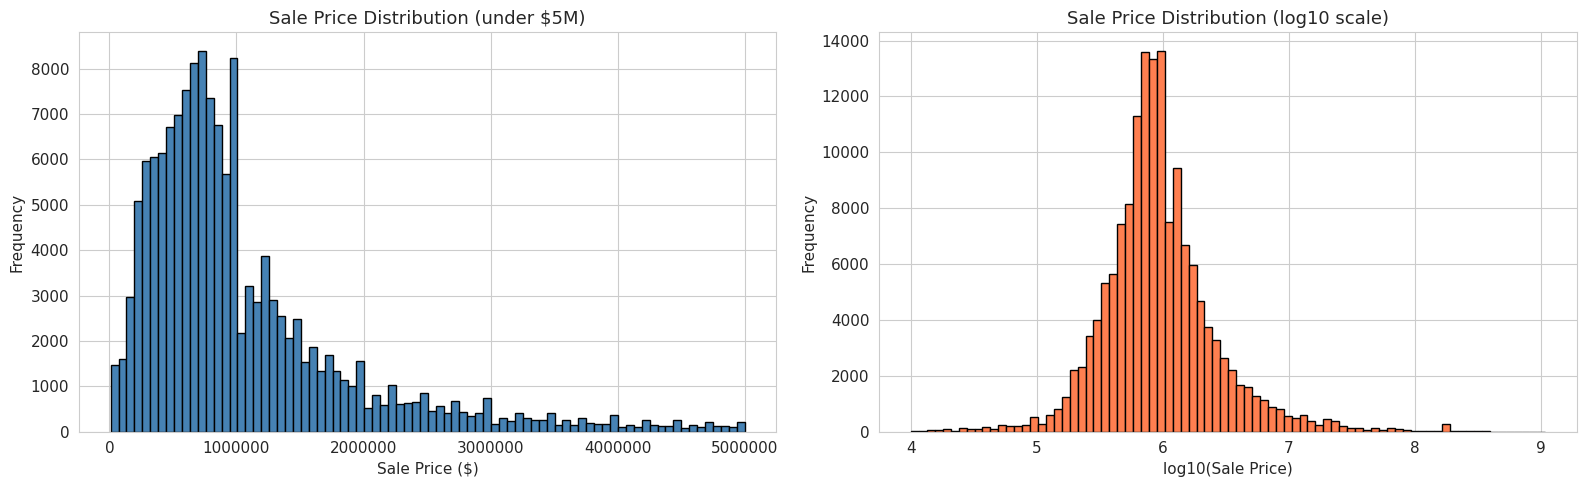


Plot saved to outputs folder.


In [6]:
# Filter only valid commercial transactions (price > $10,000)
df_valid = df[df['SALE PRICE'] > 10000].copy()

print(f"Valid transactions (price > $10,000): {len(df_valid):,}")
print(f"Removed: {len(df) - len(df_valid):,} ({(len(df) - len(df_valid))/len(df)*100:.2f}%)")

# Plot price distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram - raw prices (capped at 5M for visibility)
axes[0].hist(df_valid[df_valid['SALE PRICE'] < 5_000_000]['SALE PRICE'],
             bins=80, color='steelblue', edgecolor='black')
axes[0].set_title('Sale Price Distribution (under $5M)', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].ticklabel_format(style='plain', axis='x')

# Histogram - log scale
axes[1].hist(np.log10(df_valid['SALE PRICE']),
             bins=80, color='coral', edgecolor='black')
axes[1].set_title('Sale Price Distribution (log10 scale)', fontsize=13)
axes[1].set_xlabel('log10(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

In [7]:
# Median price by year
print("MEDIAN SALE PRICE BY YEAR:\n")
median_by_year = df_valid.groupby('sale_year')['SALE PRICE'].agg(['median', 'mean', 'count'])
median_by_year.columns = ['Median', 'Mean', 'Count']
print(median_by_year.apply(lambda col: col.map(lambda x: f'{x:,.0f}')).to_string())

# Median price by borough
print("\n\nMEDIAN SALE PRICE BY BOROUGH:\n")
median_by_borough = df_valid.groupby('borough_name')['SALE PRICE'].agg(['median', 'mean', 'count'])
median_by_borough.columns = ['Median', 'Mean', 'Count']
print(median_by_borough.sort_values('Median', ascending=False).apply(lambda col: col.map(lambda x: f'{x:,.0f}')).to_string())

MEDIAN SALE PRICE BY YEAR:

            Median       Mean   Count
sale_year                            
2023       815,000  1,905,514  49,475
2024       828,000  1,924,011  50,562
2025       885,000  3,267,282  53,609


MEDIAN SALE PRICE BY BOROUGH:

                  Median       Mean   Count
borough_name                               
manhattan      1,275,000  5,086,192  41,728
brooklyn         998,000  1,805,745  39,520
queens           710,000  1,167,162  46,198
staten_island    670,000    797,501  14,123
bronx            650,000  1,484,603  12,077


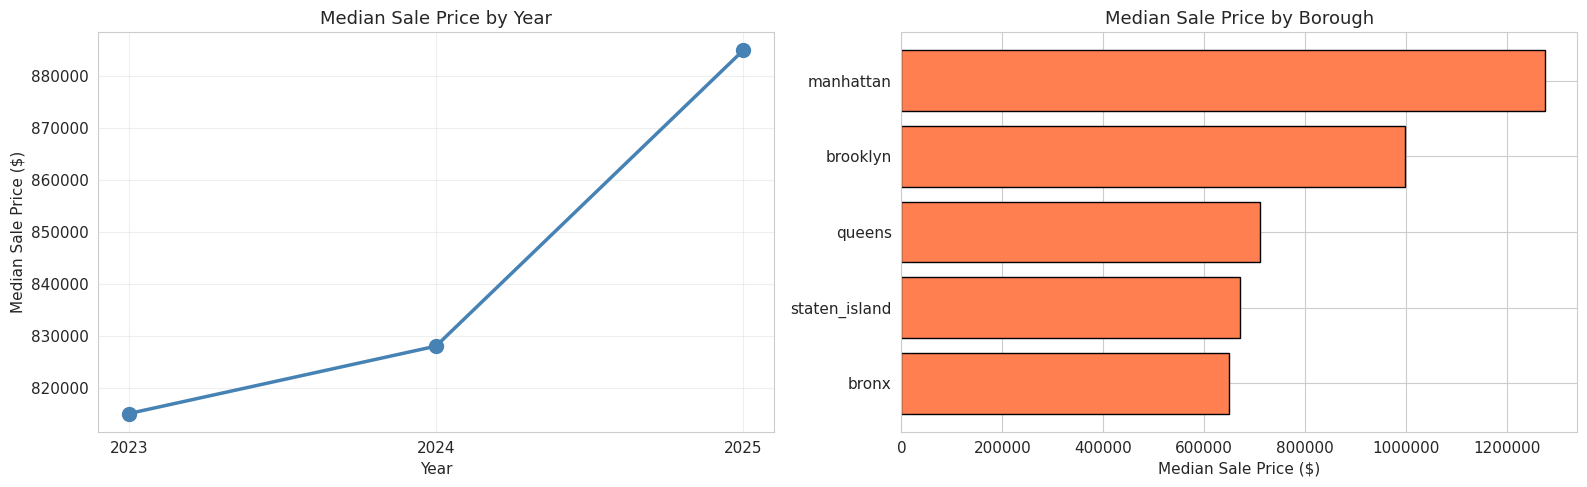


Plot saved to outputs folder.


In [8]:
# Visualize median price evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Median price by year
median_year = df_valid.groupby('sale_year')['SALE PRICE'].median()
axes[0].plot(median_year.index, median_year.values, marker='o', linewidth=2.5,
             markersize=10, color='steelblue')
axes[0].set_title('Median Sale Price by Year', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Sale Price ($)')
axes[0].set_xticks(median_year.index)
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(style='plain', axis='y')

# Median price by borough
median_borough = df_valid.groupby('borough_name')['SALE PRICE'].median().sort_values(ascending=True)
axes[1].barh(median_borough.index, median_borough.values, color='coral', edgecolor='black')
axes[1].set_title('Median Sale Price by Borough', fontsize=13)
axes[1].set_xlabel('Median Sale Price ($)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/price_by_year_borough.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

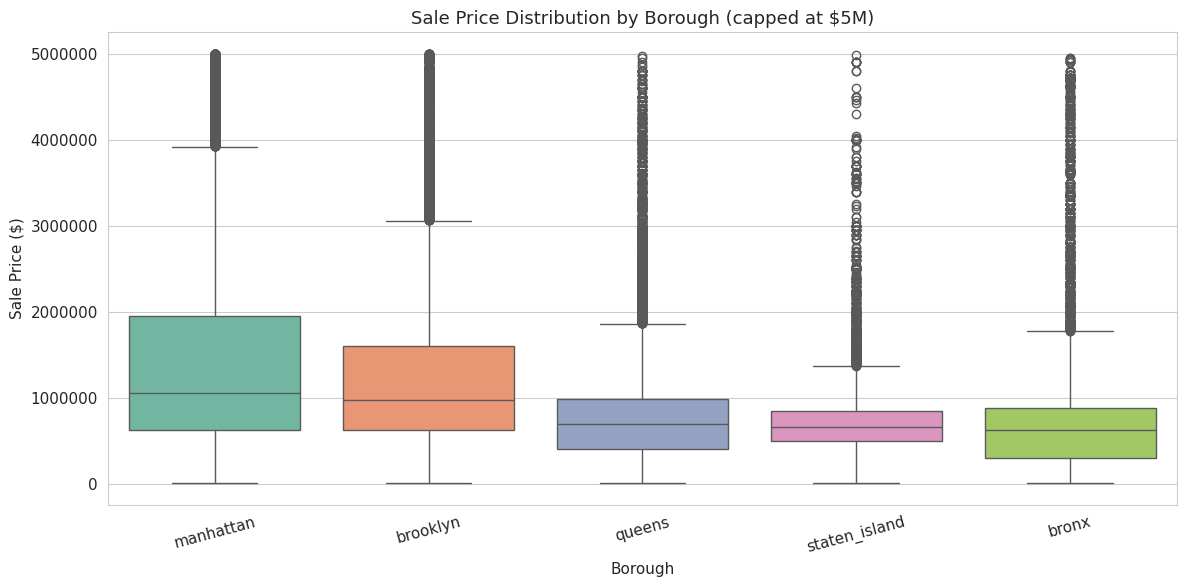


Plot saved to outputs folder.


In [9]:
# Boxplot of sale prices by borough (capped for visibility)
df_plot = df_valid[df_valid['SALE PRICE'] < 5_000_000].copy()

# Order boroughs by median price
borough_order = df_plot.groupby('borough_name')['SALE PRICE'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='borough_name', y='SALE PRICE',
            order=borough_order, palette='Set2')
plt.title('Sale Price Distribution by Borough (capped at $5M)', fontsize=13)
plt.xlabel('Borough')
plt.ylabel('Sale Price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/price_boxplot_borough.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

TOP 15 BUILDING CLASS CATEGORIES:

BUILDING CLASS CATEGORY
10 COOPS - ELEVATOR APARTMENTS       31530
01 ONE FAMILY DWELLINGS              29786
13 CONDOS - ELEVATOR APARTMENTS      28197
02 TWO FAMILY DWELLINGS              21615
09 COOPS - WALKUP APARTMENTS          6237
03 THREE FAMILY DWELLINGS             5552
07 RENTALS - WALKUP APARTMENTS        4288
15 CONDOS - 2-10 UNIT RESIDENTIAL     3206
17 CONDO COOPS                        2971
44 CONDO PARKING                      2904
04 TAX CLASS 1 CONDOS                 2873
12 CONDOS - WALKUP APARTMENTS         1893
05 TAX CLASS 1 VACANT LAND            1639
22 STORE BUILDINGS                    1519
08 RENTALS - ELEVATOR APARTMENTS       968


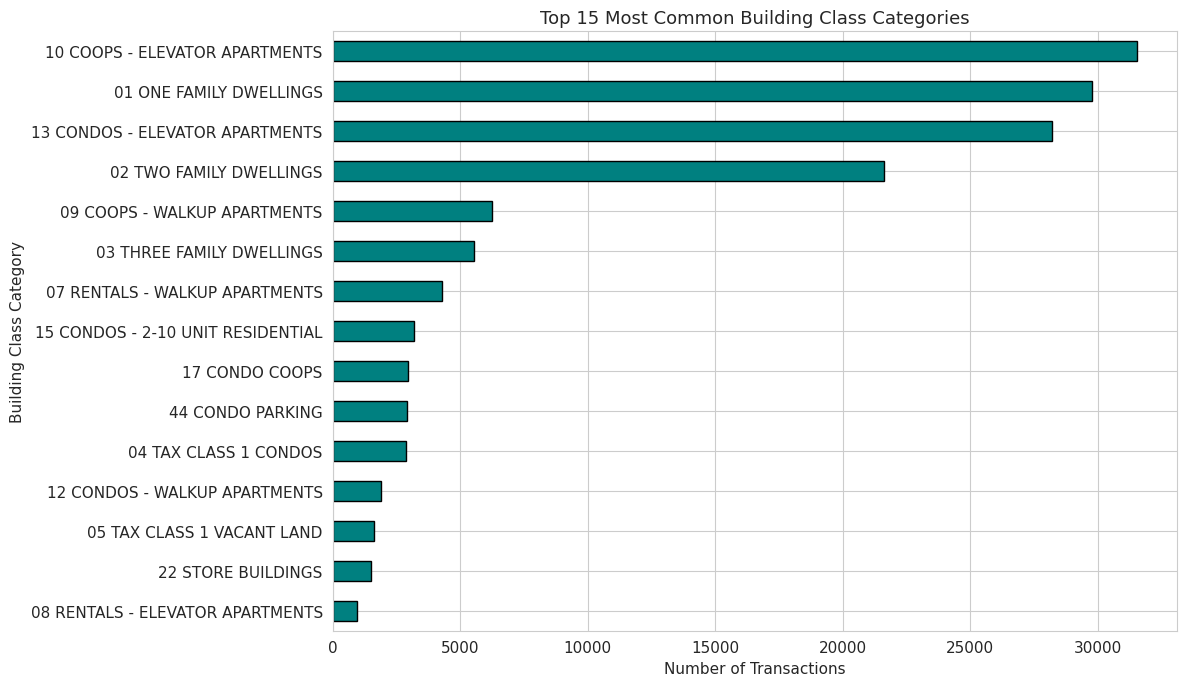


Plot saved to outputs folder.


In [10]:
# Top 15 most common building class categories
top_categories = df_valid['BUILDING CLASS CATEGORY'].value_counts().head(15)

print("TOP 15 BUILDING CLASS CATEGORIES:\n")
print(top_categories.to_string())

# Plot
plt.figure(figsize=(12, 7))
top_categories.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 15 Most Common Building Class Categories', fontsize=13)
plt.xlabel('Number of Transactions')
plt.ylabel('Building Class Category')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/top_building_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

In [13]:
# Analyze key numerical features
numerical_cols = ['LAND  SQUARE FEET', 'GROSS  SQUARE FEET', 'YEAR BUILT',
                  'TOTAL  UNITS', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS']

print("NUMERICAL FEATURES - DESCRIPTIVE STATISTICS:\n")
print(df_valid[numerical_cols].describe().round(2).to_string())

NUMERICAL FEATURES - DESCRIPTIVE STATISTICS:

       LAND  SQUARE FEET  GROSS  SQUARE FEET  YEAR BUILT  TOTAL  UNITS  RESIDENTIAL UNITS  COMMERCIAL UNITS
count           70170.00            70170.00   143557.00     112642.00          106647.00          76165.00
mean             7369.06             7478.56     1954.77          3.69               3.55              0.48
std            137090.78            49029.42       36.93         24.52              24.47              6.73
min                 0.00                0.00      190.00          0.00               0.00              0.00
25%              2000.00             1336.00     1925.00          1.00               1.00              0.00
50%              2500.00             1904.00     1950.00          1.00               1.00              0.00
75%              4000.00             2798.75     1982.00          2.00               2.00              0.00
max           9166500.00          2161994.00     2025.00       1276.00            1276.00 

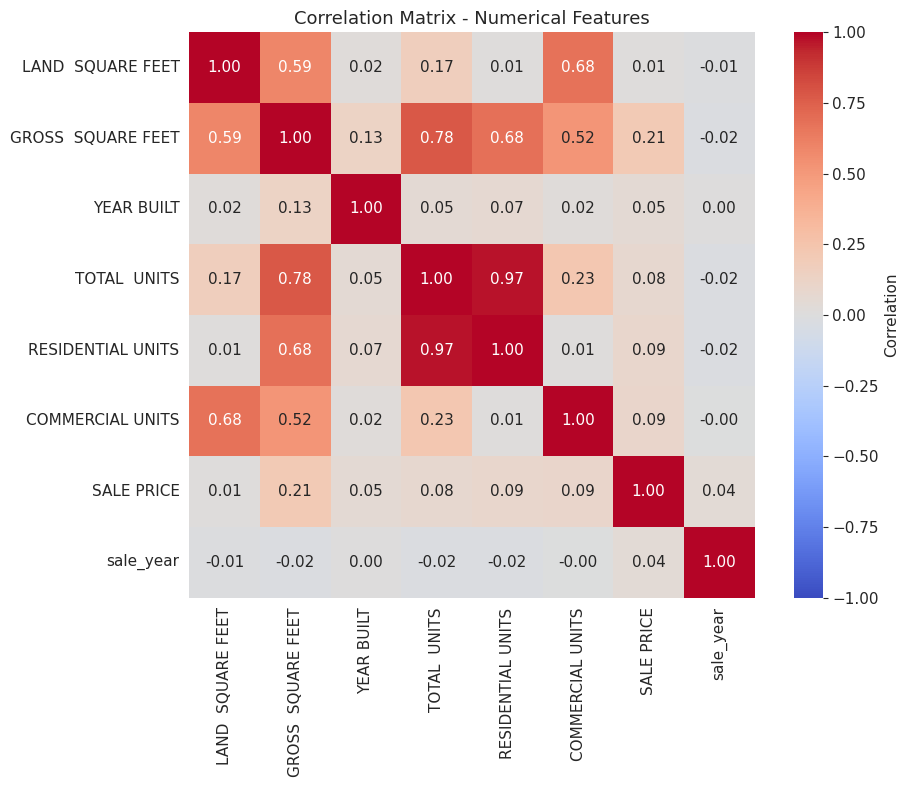


Plot saved to outputs folder.


In [14]:
# Correlation matrix between numerical features and SALE PRICE
corr_cols = numerical_cols + ['SALE PRICE', 'sale_year']

# Compute correlation
corr_matrix = df_valid[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to outputs folder.")

In [15]:
# Generate comprehensive automated EDA report
from ydata_profiling import ProfileReport

print("Generating profiling report... (this may take 1-2 minutes)\n")

# Use a sample for speed (full dataset is too large)
df_sample = df_valid.sample(n=min(50000, len(df_valid)), random_state=42)

profile = ProfileReport(df_sample,
                        title='NYC Housing Sales - EDA Report',
                        minimal=True,
                        explorative=True)

# Save report as HTML
report_path = f'{OUTPUTS_PATH}/eda_report.html'
profile.to_file(report_path)

print(f"Report saved successfully!")
print(f"   Path: {report_path}")
print(f"   You can download it from Google Drive and open in browser")

Generating profiling report... (this may take 1-2 minutes)



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:02<00:00, 10.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved successfully!
   Path: /content/drive/MyDrive/ColabProjects/housing-prices-ml/outputs/eda_report.html
   You can download it from Google Drive and open in browser


In [16]:
# Final summary of Notebook 02
print("="*60)
print("NOTEBOOK 02 - EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset overview:")
print(f"   Total records: {df.shape[0]:,}")
print(f"   Valid transactions (price > $10K): {len(df_valid):,}")
print(f"   Records removed: {len(df) - len(df_valid):,} ({(len(df)-len(df_valid))/len(df)*100:.2f}%)")

print(f"\nKey findings:")
print(f"   - 33.76% of transactions have price = $0 (non-commercial transfers)")
print(f"   - Sale price is highly skewed; log transformation will be applied")
print(f"   - Manhattan has the highest median price ($1.275M)")
print(f"   - Bronx has the lowest median price ($650K)")
print(f"   - Prices increased ~8.6% from 2023 to 2025")
print(f"   - Strong multicollinearity between TOTAL UNITS and RESIDENTIAL UNITS (0.97)")
print(f"   - Weak linear correlations -> non-linear models recommended")

print(f"\nMissing values to address:")
print(f"   - EASE-MENT: 100% missing (will be dropped)")
print(f"   - APARTMENT NUMBER: 76% missing (will be dropped)")
print(f"   - LAND/GROSS SQUARE FEET: ~45% missing (imputation needed)")
print(f"   - YEAR BUILT: 6.6% missing (imputation needed)")

print(f"\nOutput files generated:")
print(f"   - price_distribution.png")
print(f"   - price_by_year_borough.png")
print(f"   - price_boxplot_borough.png")
print(f"   - top_building_categories.png")
print(f"   - correlation_matrix.png")
print(f"   - eda_report.html")

print("\n" + "="*60)
print("Notebook 02 completed successfully.")
print("Next step: Notebook 03 - Data Preprocessing & Feature Engineering")
print("="*60)

NOTEBOOK 02 - EXPLORATORY DATA ANALYSIS SUMMARY

Dataset overview:
   Total records: 239,722
   Valid transactions (price > $10K): 153,646
   Records removed: 86,076 (35.91%)

Key findings:
   - 33.76% of transactions have price = $0 (non-commercial transfers)
   - Sale price is highly skewed; log transformation will be applied
   - Manhattan has the highest median price ($1.275M)
   - Bronx has the lowest median price ($650K)
   - Prices increased ~8.6% from 2023 to 2025
   - Strong multicollinearity between TOTAL UNITS and RESIDENTIAL UNITS (0.97)
   - Weak linear correlations -> non-linear models recommended

Missing values to address:
   - EASE-MENT: 100% missing (will be dropped)
   - APARTMENT NUMBER: 76% missing (will be dropped)
   - LAND/GROSS SQUARE FEET: ~45% missing (imputation needed)
   - YEAR BUILT: 6.6% missing (imputation needed)

Output files generated:
   - price_distribution.png
   - price_by_year_borough.png
   - price_boxplot_borough.png
   - top_building_categori